In [1]:
import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.utils.data import DataLoader

from min_vit.model import MinViT
from min_vit.dataset import full_train_dataset, train_dataset, val_dataset, test_dataset
from min_vit.train import train_one_epoch, eval_one_epoch, train

ModuleNotFoundError: No module named 'min_vit'

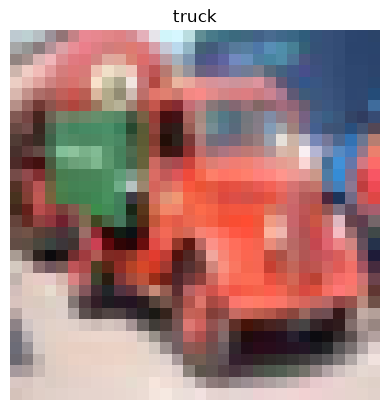

In [19]:
classes = full_train_dataset.classes

image, label = train_dataset[123] # type: ignore
image = image.permute(1, 2, 0)

class_name = classes[label]

plt.imshow(image)
plt.title(class_name)
plt.axis('off')
plt.show()

In [20]:
train_dataloader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

val_dataloader = DataLoader(
    val_dataset,
    batch_size=64,
    shuffle=False
)

test_dataloader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False
)

In [21]:
def accuracy(preds, targets):
    return (preds == targets).float().mean()

In [22]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

model = MinViT()

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-3
)
loss_func = nn.CrossEntropyLoss()

metrics = train_one_epoch(
    model, train_dataloader, 
    optimizer, loss_func, 
    accuracy, device
)

print(metrics)

  0%|          | 0/704 [00:00<?, ?it/s]

 12%|█▎        | 88/704 [00:31<03:38,  2.82it/s]


KeyboardInterrupt: 